# 32 — Apply the Risk Factor Eligibility Test

Determine which IMA factors are Modellable Risk Factors and which are Non-Modellable Risk Factors.

RFET means Risk Factor Eligibility Test. MRF means Modellable Risk Factor. NMRF means Non-Modellable Risk Factor. The observation records here are synthetic transaction and committed-quote events, not public closing prices.

This step uses: Synthetic qualifying observation dates and the factor inventory.

It produces: A factor-level pass or fail, route used and plain-language reason.

> Basel norm applied: MAR31.13 permits either 24 observations with continuity or 100 observations over 12 months, with at most one observation per day.

$$MRF_k=1\{N_k\ge100\ \text{or}\ (N_k\ge24\ \text{and continuity passes})\}$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260908T033903126517Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
rfet=stage('03_rfet_results'); obs=stage('02_synthetic_rpo_observations')
display(rfet[['risk_factor_id','qualifying_observation_count','minimum_observations_in_any_90_days','rfet_route','modellability_status','rfet_reason']])
worked=rfet.iloc[0]
print(f"Worked factor {worked.risk_factor_id}: {worked.qualifying_observation_count} qualifying dates and minimum {worked.minimum_observations_in_any_90_days} in any 90-day window → {worked.modellability_status}")

,risk_factor_id,qualifying_observation_count,minimum_observations_in_any_90_days,rfet_route,modellability_status,rfet_reason
0,APPLE,118,28,100_OBSERVATION_ROUTE,MRF,Passed 100 observation route with 118 qualifyi...
1,AXIS_BANK_5.0Y,32,7,24_PLUS_CONTINUITY_ROUTE,MRF,Passed 24 plus continuity route with 32 qualif...
2,BRENT_0.25Y_GLOBAL,118,28,100_OBSERVATION_ROUTE,MRF,Passed 100 observation route with 118 qualifyi...
3,BRENT_0.5Y_GLOBAL,118,28,100_OBSERVATION_ROUTE,MRF,Passed 100 observation route with 118 qualifyi...
4,BRENT_1.0Y_GLOBAL,118,28,100_OBSERVATION_ROUTE,MRF,Passed 100 observation route with 118 qualifyi...
5,BRENT_VOL_0.5Y,32,7,24_PLUS_CONTINUITY_ROUTE,MRF,Passed 24 plus continuity route with 32 qualif...
6,CDX_IG_S42_3_7_5.0Y,14,0,NO_ROUTE_PASSED,NMRF,Failed: 14 qualifying dates and minimum 0 obse...
7,CDX_IG_S42_5.0Y,32,7,24_PLUS_CONTINUITY_ROUTE,MRF,Passed 24 plus continuity route with 32 qualif...
8,EURINR,118,28,100_OBSERVATION_ROUTE,MRF,Passed 100 observation route with 118 qualifyi...
9,EURINR_VOL_1.0Y,32,7,24_PLUS_CONTINUITY_ROUTE,MRF,Passed 24 plus continuity route with 32 qualif...


Worked factor APPLE: 118 qualifying dates and minimum 28 in any 90-day window → MRF


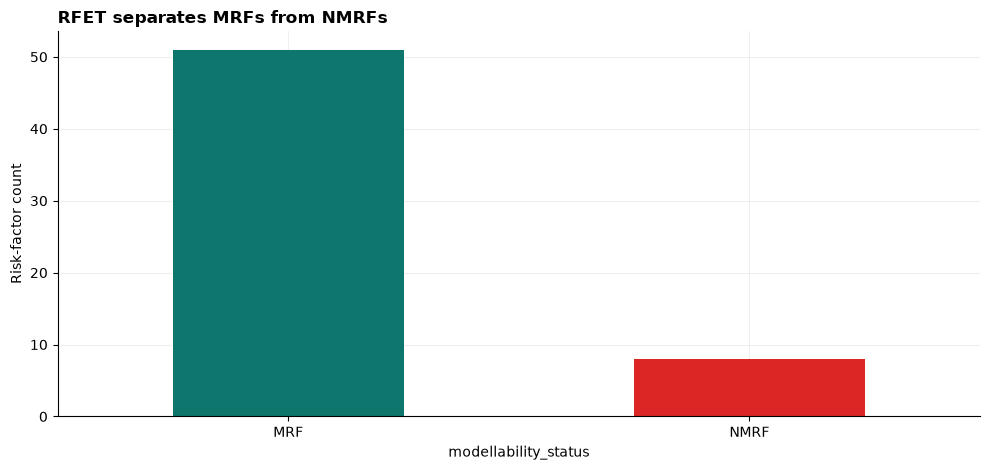

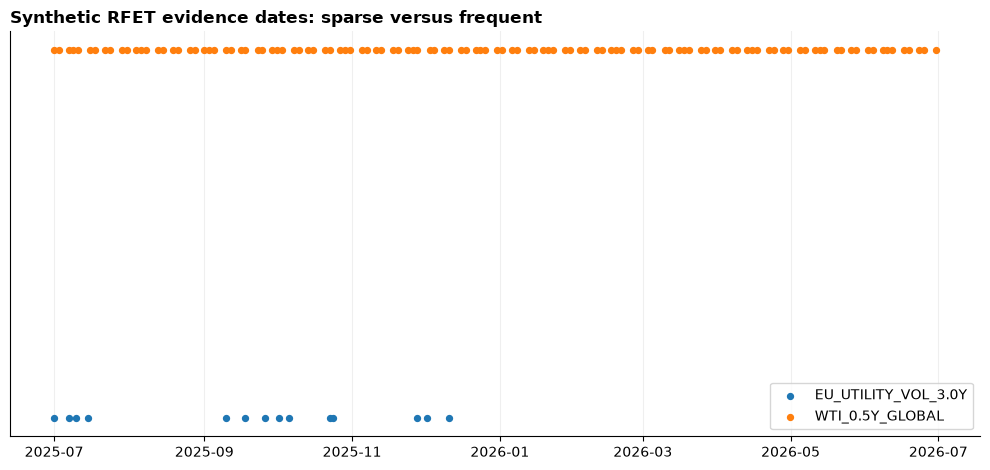

In [3]:
counts=rfet.modellability_status.value_counts(); ax=counts.plot(kind='bar',color=['#0F766E','#DC2626']); ax.set_ylabel('Risk-factor count'); ax.set_title('RFET separates MRFs from NMRFs',loc='left',weight='bold'); ax.tick_params(axis='x',rotation=0); plt.tight_layout(); plt.show()
examples=rfet.sort_values('qualifying_observation_count').iloc[[0,-1]].risk_factor_id.tolist(); sample=obs[obs.risk_factor_id.isin(examples)].copy(); sample['observation_date']=pd.to_datetime(sample.observation_date)
fig,ax=plt.subplots();
for y,(factor,g) in enumerate(sample.groupby('risk_factor_id')): ax.scatter(g.observation_date,[y]*len(g),s=18,label=factor)
ax.set_yticks([]); ax.set_title('Synthetic RFET evidence dates: sparse versus frequent',loc='left',weight='bold'); ax.legend(); plt.tight_layout(); plt.show()

The first chart counts factors classified as Modellable Risk Factors (MRFs) and Non-Modellable Risk Factors (NMRFs) after RFET. The second chart shows the actual synthetic qualifying-observation dates for the sparsest and most frequently observed factors. Dense, well-spread dates support modellability; sparse dates explain why a factor can fail RFET.